In [5]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt
from scipy.spatial import distance 
import plotly.express as ex
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,PowerTransformer,LabelEncoder,OrdinalEncoder 
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import SVC 
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
import seaborn as sns
import joblib 
import datetime
import warnings 
from sklearn.feature_selection import SelectKBest,f_classif 
warnings.filterwarnings('ignore')


In [6]:
df1=pd.read_csv(r"../DataFolder/marriage_data_india.csv",encoding_errors='ignore')

In [7]:
df2=df1.copy()

In [8]:
def sample_checks(df2):
    print(df2.info())
    print(df2.describe())
    print(df2.ndim)
    print(df2.shape)
    print(df2.size)
sample_checks(df2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    10000 non-null  int64 
 1   Marriage_Type         10000 non-null  object
 2   Age_at_Marriage       10000 non-null  int64 
 3   Gender                10000 non-null  object
 4   Education_Level       10000 non-null  object
 5   Caste_Match           10000 non-null  object
 6   Religion              10000 non-null  object
 7   Parental_Approval     10000 non-null  object
 8   Urban_Rural           10000 non-null  object
 9   Dowry_Exchanged       10000 non-null  object
 10  Marital_Satisfaction  10000 non-null  object
 11  Divorce_Status        10000 non-null  object
 12  Children_Count        10000 non-null  int64 
 13  Income_Level          10000 non-null  object
 14  Years_Since_Marriage  10000 non-null  int64 
 15  Spouse_Working        10000 non-null 

In [9]:
def sample_null_duplicates_empty(df2):
    print(df2.isna().sum())
    print("--------------")
    print(df2.isnull().sum())
    print('-----------------------')
    print(df2.duplicated())

sample_null_duplicates_empty(df2)

ID                      0
Marriage_Type           0
Age_at_Marriage         0
Gender                  0
Education_Level         0
Caste_Match             0
Religion                0
Parental_Approval       0
Urban_Rural             0
Dowry_Exchanged         0
Marital_Satisfaction    0
Divorce_Status          0
Children_Count          0
Income_Level            0
Years_Since_Marriage    0
Spouse_Working          0
Inter-Caste             0
Inter-Religion          0
dtype: int64
--------------
ID                      0
Marriage_Type           0
Age_at_Marriage         0
Gender                  0
Education_Level         0
Caste_Match             0
Religion                0
Parental_Approval       0
Urban_Rural             0
Dowry_Exchanged         0
Marital_Satisfaction    0
Divorce_Status          0
Children_Count          0
Income_Level            0
Years_Since_Marriage    0
Spouse_Working          0
Inter-Caste             0
Inter-Religion          0
dtype: int64
-----------------------

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [10]:
df2.drop_duplicates(inplace=True)

In [11]:
numeric_cols=df2.select_dtypes(include='number',exclude='object').columns
numeric_cols

Index(['ID', 'Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage'], dtype='object')

In [12]:
def separate_numeric_cata(df2):
    print('------------------------')
    numeric_cols=df2.select_dtypes(include='number',exclude='object').columns
    # print("numeric cols are :{}".format(numeric_cols))
    print(numeric_cols.tolist())
    print('-------------------------')
    cata_cols=df2.select_dtypes(include='object',exclude='number').columns
    print(cata_cols.tolist())
    print('---------------------------')
separate_numeric_cata(df2)

------------------------
['ID', 'Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage']
-------------------------
['Marriage_Type', 'Gender', 'Education_Level', 'Caste_Match', 'Religion', 'Parental_Approval', 'Urban_Rural', 'Dowry_Exchanged', 'Marital_Satisfaction', 'Divorce_Status', 'Income_Level', 'Spouse_Working', 'Inter-Caste', 'Inter-Religion']
---------------------------


In [13]:
df3=df2.copy()

In [14]:
label=LabelEncoder()
df3['Marriage_Type_Encoded']=label.fit_transform(df3['Marriage_Type'])

In [15]:
df3[['Marriage_Type_Encoded','Marriage_Type']].value_counts()

Marriage_Type_Encoded  Marriage_Type
0                      Arranged         6022
1                      Love             3978
Name: count, dtype: int64

In [16]:
ordinal=OrdinalEncoder(dtype='int')
df3[['Gender_encoded', 'Education_Level_encoded', 'Caste_Match_encoded', 'Religion_encoded', 'Parental_Approval_encoded', 'Urban_Rural_encoded', 'Dowry_Exchanged_encoded', 'Marital_Satisfaction_encoded', 'Divorce_Status_encoded', 'Income_Level_encoded', 'Spouse_Working_encoded', 'Inter-Caste_encoded', 'Inter-Religion_encoded']]=ordinal.fit_transform(df3[['Gender', 'Education_Level', 'Caste_Match', 'Religion', 'Parental_Approval', 'Urban_Rural', 'Dowry_Exchanged', 'Marital_Satisfaction', 'Divorce_Status', 'Income_Level', 'Spouse_Working', 'Inter-Caste', 'Inter-Religion']])

In [17]:
df3.sample(10)

,ID,Marriage_Type,Age_at_Marriage,Gender,Education_Level,Caste_Match,Religion,Parental_Approval,Urban_Rural,Dowry_Exchanged,...,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded
1303,1304,Arranged,18,Female,Graduate,Same,Hindu,Yes,Urban,Yes,...,1,2,1,2,2,0,2,1,0,0
6856,6857,Arranged,21,Female,Graduate,Same,Hindu,Partial,Urban,No,...,1,1,1,0,1,0,2,1,0,0
1114,1115,Arranged,35,Male,Graduate,Same,Christian,Yes,Rural,No,...,0,2,0,0,0,0,2,0,0,1
540,541,Love,32,Male,Graduate,Same,Hindu,Yes,Urban,No,...,1,2,1,0,0,0,2,1,1,0
8627,8628,Arranged,32,Male,Graduate,Same,Muslim,Yes,Rural,No,...,2,2,0,0,2,0,2,1,0,1
6582,6583,Love,33,Female,Graduate,Same,Hindu,Yes,Rural,Not Disclosed,...,1,2,0,1,0,0,2,1,0,1
4696,4697,Arranged,26,Male,Graduate,Same,Hindu,Yes,Urban,No,...,1,2,1,0,0,1,1,0,0,1
9558,9559,Arranged,32,Male,PhD,Same,Hindu,Partial,Urban,Yes,...,1,1,1,2,0,0,0,1,0,0
5297,5298,Arranged,26,Female,School,Same,Others,Yes,Urban,No,...,3,2,1,0,2,0,2,1,0,0
4188,4189,Love,27,Male,Graduate,Same,Hindu,Partial,Urban,Not Disclosed,...,1,1,1,1,1,0,1,0,1,0


In [18]:
df4=df3.copy()

In [19]:
df4.drop(columns=['Marriage_Type', 'Gender', 'Education_Level', 'Caste_Match', 'Religion', 'Parental_Approval', 'Urban_Rural', 'Dowry_Exchanged', 'Marital_Satisfaction', 'Divorce_Status', 'Income_Level', 'Spouse_Working', 'Inter-Caste', 'Inter-Religion'],axis=1,inplace=True)

In [20]:
df4.sample(10)

,ID,Age_at_Marriage,Children_Count,Years_Since_Marriage,Marriage_Type_Encoded,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded
3253,3254,29,5,30,0,1,0,1,1,2,1,0,0,0,2,0,1,0
7564,7565,39,4,4,0,1,0,0,1,1,0,2,2,0,0,0,0,0
9620,9621,37,3,48,0,1,0,0,4,2,0,0,2,0,2,1,0,0
790,791,34,1,43,1,0,0,1,1,2,1,0,0,1,1,1,0,0
4603,4604,22,2,14,1,0,0,1,1,1,0,0,0,0,2,0,0,0
3810,3811,22,3,49,0,1,1,1,1,2,0,0,2,0,0,0,1,0
1991,1992,26,5,8,1,0,3,0,1,1,0,2,2,0,0,1,0,0
4019,4020,29,5,49,0,1,3,0,1,2,0,1,0,0,1,1,0,0
5061,5062,21,4,20,1,1,0,0,2,1,0,2,1,0,1,1,0,0
304,305,35,1,1,1,0,3,1,1,2,1,1,2,0,0,1,0,0


In [21]:
df4.drop(columns=['ID'],axis=1,inplace=True)

In [22]:
df4.head(10)

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Marriage_Type_Encoded,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded
0,23,5,34,1,1,0,0,1,0,1,0,2,1,2,0,0,0
1,28,3,42,1,0,3,1,1,2,0,2,1,0,2,0,0,1
2,39,0,25,0,1,2,1,2,2,0,0,2,0,0,0,0,0
3,26,0,12,0,0,3,0,1,2,1,2,1,0,0,0,1,0
4,32,1,41,1,0,0,1,1,1,0,2,2,0,2,0,0,1
5,37,4,3,1,0,3,0,1,2,1,2,0,0,1,0,0,0
6,24,2,15,0,1,0,0,1,2,0,0,2,0,2,0,0,0
7,18,4,21,0,1,2,1,4,2,0,2,2,0,2,0,1,0
8,22,4,37,0,0,2,1,0,2,0,1,0,0,1,0,0,1
9,24,5,17,0,1,3,1,1,0,1,0,2,0,0,0,1,0


In [23]:
df4.columns

Index(['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage',
       'Marriage_Type_Encoded', 'Gender_encoded', 'Education_Level_encoded',
       'Caste_Match_encoded', 'Religion_encoded', 'Parental_Approval_encoded',
       'Urban_Rural_encoded', 'Dowry_Exchanged_encoded',
       'Marital_Satisfaction_encoded', 'Divorce_Status_encoded',
       'Income_Level_encoded', 'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded'],
      dtype='object')

In [24]:
df5=pd.DataFrame(data=df4,columns=['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage', 'Gender_encoded', 'Education_Level_encoded',
       'Caste_Match_encoded', 'Religion_encoded', 'Parental_Approval_encoded',
       'Urban_Rural_encoded', 'Dowry_Exchanged_encoded',
       'Marital_Satisfaction_encoded', 'Divorce_Status_encoded',
       'Income_Level_encoded', 'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded','Marriage_Type_Encoded'],dtype='int')

In [25]:
df5.sample(10)

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded,Marriage_Type_Encoded
1821,24,0,39,0,3,0,1,2,1,0,0,0,0,1,0,0,1
2999,28,0,12,0,2,0,1,2,1,0,2,1,2,0,1,0,1
5857,29,2,23,1,2,1,1,2,1,0,0,0,1,0,0,0,0
2871,35,0,49,0,3,1,1,2,1,2,0,0,0,0,0,0,0
8925,20,1,31,0,3,1,2,2,0,0,2,0,2,1,1,1,0
8200,34,1,22,1,0,1,1,0,1,0,2,0,0,1,0,0,1
8765,29,1,20,1,3,0,1,0,1,2,2,0,0,0,0,1,0
1491,34,1,17,0,0,0,1,1,0,2,0,0,1,1,0,0,0
9396,19,3,18,0,3,0,1,2,0,2,2,0,2,0,0,0,0
4316,29,5,5,0,3,0,0,2,0,0,2,1,1,1,0,0,0


each column name is Age_at_Marriage no anomolies found
incase of no anomolies


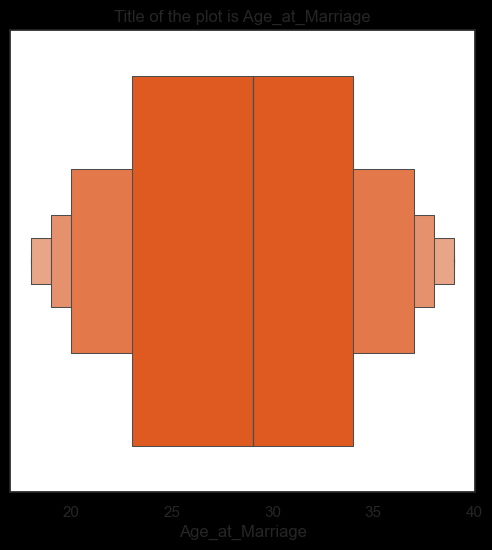

each column name is Years_Since_Marriage no anomolies found
incase of no anomolies


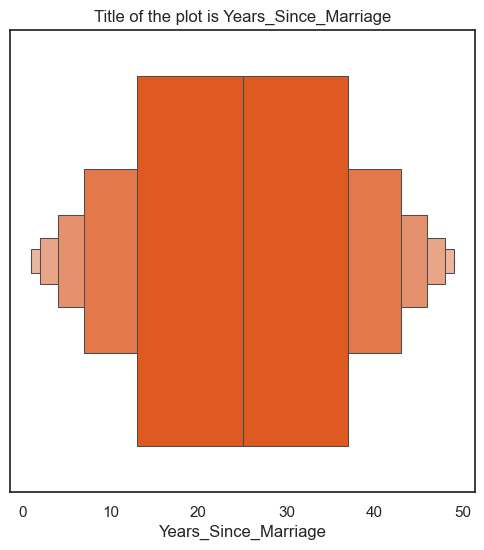

new shape (10000, 17) and old shape is (10000, 17)


In [26]:
class Anomolie_detection:
    def __init__(self,data):
        self.data=data
    def anomolies_function(self,col):
        Q1=self.data[col].quantile(0.25)
        Q3=self.data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        mask = (self.data[col]< lower_bound) | (self.data[col]>upper_bound)
        anomolies_index=self.data[mask].index.tolist()
        anomolies_data=self.data[col][anomolies_index].tolist()
        return anomolies_index, anomolies_data
numeric_col1=df5[['Age_at_Marriage','Years_Since_Marriage']]
Anomolies_detection_instance=Anomolie_detection(df5)
index_store=set()
for each_col in numeric_col1:
    ano_index,ano_data=Anomolies_detection_instance.anomolies_function(each_col)
    if ano_index:
        print(f"each col --> {each_col} -- anomolies indexes--> {ano_index} -- and data is{ano_data}")
        print(f"before removing the anomolies data ---> {each_col}")
        cl1=['#ff4d01','#ffffff']
        plt.figure(figsize=(6,6))
        sns.set_theme(style='white',palette=cl1)
        sns.boxenplot(x=df5[each_col])
        plt.title(f"Title of the plot is {each_col}")
        plt.savefig(f"{each_col}.png",dpi=100)
        plt.show()
        index_store.update(ano_index)
    else:
        print(f"each column name is {each_col} no anomolies found")
        print("incase of no anomolies")
        cl1=['#ff4d01','#ffffff']
        plt.figure(figsize=(6,6))
        sns.set_theme(style='white',palette=cl1)
        sns.boxenplot(x=df5[each_col])
        plt.title(f"Title of the plot is {each_col}")
        plt.savefig(f"{each_col}.jpeg",dpi=100)
        plt.show()
df6=df5.drop(list(index_store),axis=0)
print(f"new shape {df6.shape} and old shape is {df5.shape}")   

In [27]:
pearson=df6.corr(method='pearson').round(2)
pearson

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded,Marriage_Type_Encoded
Age_at_Marriage,1.00,-0.01,0.00,0.00,0.01,-0.01,0.01,-0.00,0.00,0.01,0.00,0.02,0.00,0.00,0.00,-0.02,0.01
Children_Count,-0.01,1.00,0.00,0.01,-0.01,-0.00,-0.00,-0.01,-0.00,0.00,0.01,-0.01,0.02,0.00,-0.01,-0.00,-0.02
Years_Since_Marriage,0.00,0.00,1.00,0.01,-0.01,-0.02,0.01,0.01,-0.02,-0.00,-0.00,0.01,-0.00,-0.01,-0.02,0.01,-0.02
Gender_encoded,0.00,0.01,0.01,1.00,-0.01,0.01,-0.00,0.01,-0.00,-0.00,-0.00,-0.01,0.00,-0.01,0.00,-0.02,-0.01
Education_Level_encoded,0.01,-0.01,-0.01,-0.01,1.00,0.00,0.01,-0.00,-0.00,0.01,-0.01,-0.01,0.00,0.00,-0.00,-0.01,-0.01
Caste_Match_encoded,-0.01,-0.00,-0.02,0.01,0.00,1.00,-0.00,-0.01,0.00,-0.01,-0.00,0.01,0.00,-0.02,-0.00,-0.01,-0.01
Religion_encoded,0.01,-0.00,0.01,-0.00,0.01,-0.00,1.00,0.00,-0.00,0.00,0.01,-0.00,0.01,0.01,-0.00,0.01,0.02
Parental_Approval_encoded,-0.00,-0.01,0.01,0.01,-0.00,-0.01,0.00,1.00,0.00,-0.00,0.00,0.00,0.02,-0.02,0.01,-0.01,-0.02
Urban_Rural_encoded,0.00,-0.00,-0.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.02,0.02,0.01,-0.02,0.00,0.02,-0.01,0.00
Dowry_Exchanged_encoded,0.01,0.00,-0.00,-0.00,0.01,-0.01,0.00,-0.00,-0.02,1.00,-0.01,0.01,0.00,0.00,0.00,-0.02,0.01


In [28]:
spearman=df6.corr(method='spearman').round(2)
spearman

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded,Marriage_Type_Encoded
Age_at_Marriage,1.00,-0.01,0.00,0.00,0.01,-0.01,-0.00,-0.01,0.00,0.01,0.00,0.02,0.00,0.00,0.00,-0.02,0.01
Children_Count,-0.01,1.00,0.00,0.01,-0.01,-0.00,-0.01,-0.01,-0.00,0.00,0.01,-0.01,0.02,0.00,-0.01,-0.00,-0.02
Years_Since_Marriage,0.00,0.00,1.00,0.01,-0.01,-0.02,0.01,0.02,-0.02,-0.00,-0.00,0.01,-0.00,-0.01,-0.02,0.01,-0.02
Gender_encoded,0.00,0.01,0.01,1.00,-0.01,0.01,-0.00,0.02,-0.00,-0.01,-0.00,-0.01,0.00,-0.01,0.00,-0.02,-0.01
Education_Level_encoded,0.01,-0.01,-0.01,-0.01,1.00,0.00,0.02,-0.01,-0.00,0.01,-0.01,-0.01,0.00,0.00,-0.00,-0.01,-0.01
Caste_Match_encoded,-0.01,-0.00,-0.02,0.01,0.00,1.00,-0.01,-0.01,0.00,-0.01,-0.00,0.01,0.00,-0.02,-0.00,-0.01,-0.01
Religion_encoded,-0.00,-0.01,0.01,-0.00,0.02,-0.01,1.00,0.01,-0.00,0.00,0.00,0.00,-0.00,0.02,-0.00,0.01,0.02
Parental_Approval_encoded,-0.01,-0.01,0.02,0.02,-0.01,-0.01,0.01,1.00,0.00,-0.00,0.01,0.01,0.02,-0.01,0.01,-0.01,-0.01
Urban_Rural_encoded,0.00,-0.00,-0.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.02,0.02,0.01,-0.02,0.00,0.02,-0.01,0.00
Dowry_Exchanged_encoded,0.01,0.00,-0.00,-0.01,0.01,-0.01,0.00,-0.00,-0.02,1.00,-0.01,0.01,0.00,0.01,0.00,-0.02,0.01


In [29]:
df6.columns

Index(['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage',
       'Gender_encoded', 'Education_Level_encoded', 'Caste_Match_encoded',
       'Religion_encoded', 'Parental_Approval_encoded', 'Urban_Rural_encoded',
       'Dowry_Exchanged_encoded', 'Marital_Satisfaction_encoded',
       'Divorce_Status_encoded', 'Income_Level_encoded',
       'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded', 'Marriage_Type_Encoded'],
      dtype='object')

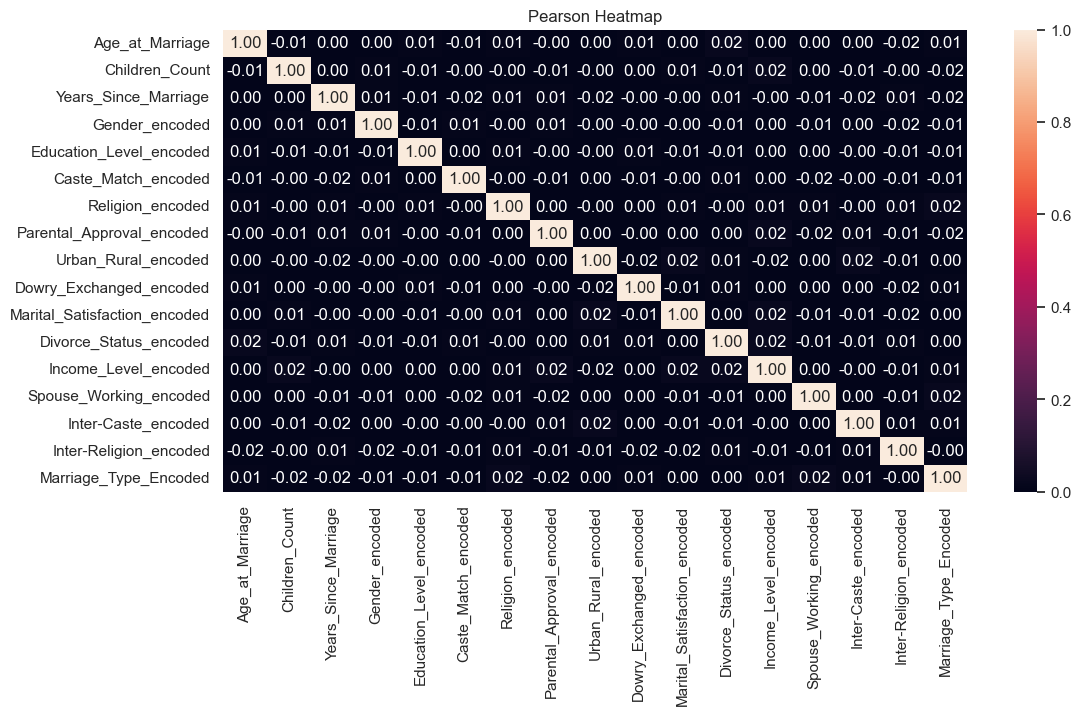

In [30]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(12,6))
sns.set_theme(style='white',palette=cl1)
fig=sns.heatmap(data=pearson,annot=True,vmax=1,vmin=0,fmt='.2f')
fig.set_mouseover(True)
plt.title("Pearson Heatmap")
plt.grid(True)
plt.show()

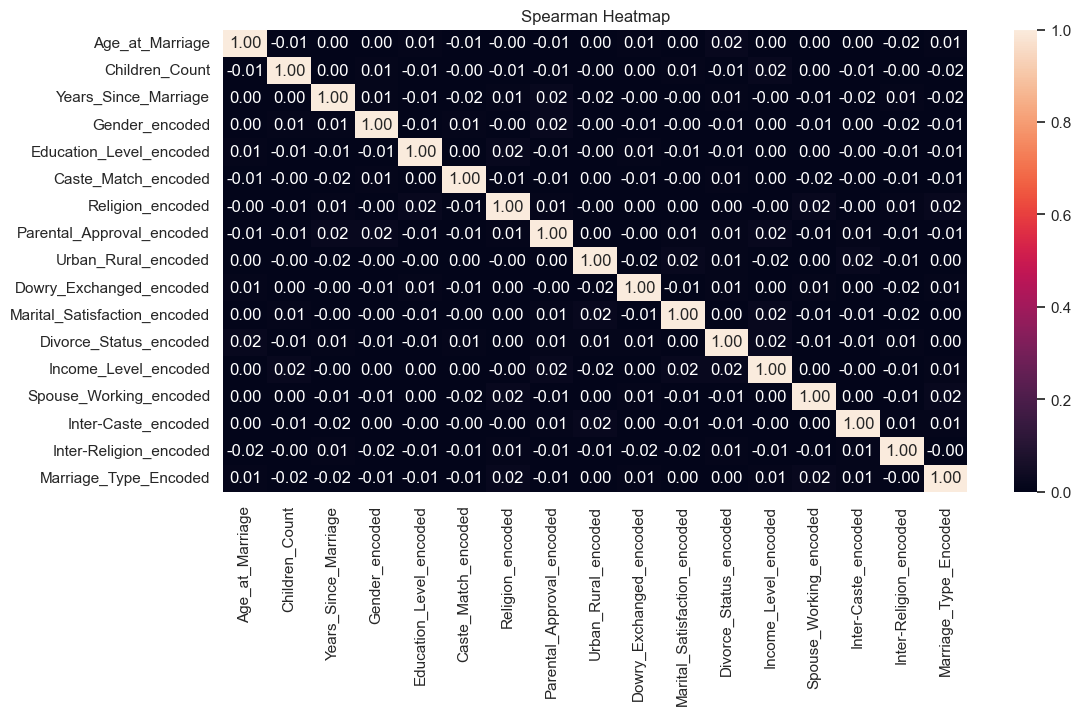

In [31]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(12,6))
sns.set_theme(style='white',palette=cl1)
fig=sns.heatmap(data=spearman,annot=True,vmax=1,vmin=0,fmt='.2f')
fig.set_mouseover(True)
plt.title("Spearman Heatmap")
plt.grid(True)
plt.show()

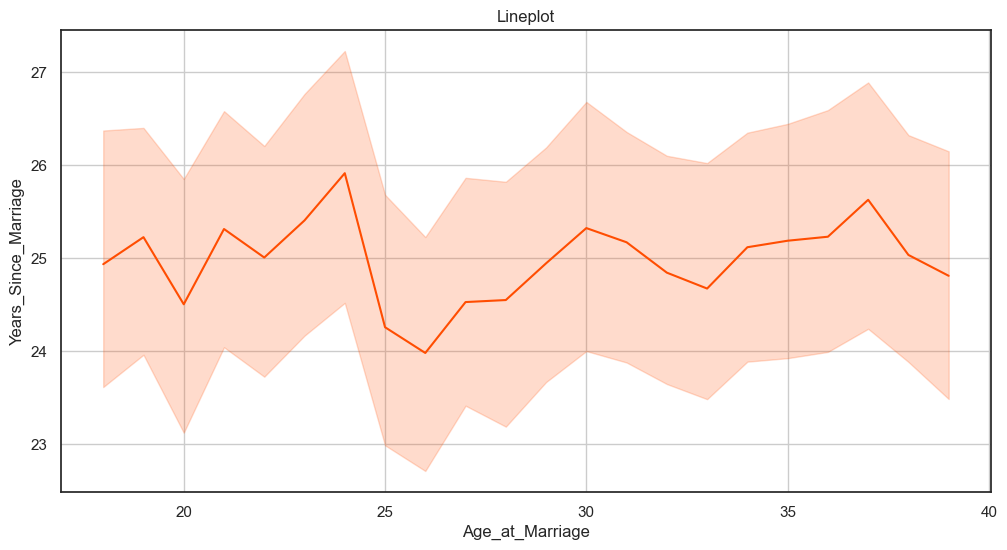

In [32]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(12,6))
sns.set_theme(style='white',palette=cl1)
sns.lineplot(data=df6,x=df6['Age_at_Marriage'],y=df6['Years_Since_Marriage'])
plt.title("Lineplot")
plt.grid(True)
plt.show()

In [33]:

ex.box(data_frame=df6,x=df6['Age_at_Marriage'],y=df6['Years_Since_Marriage'],title='Box Plot',subtitle='Age at marraiage VS Yrs Since Marriage',hover_name=df6['Age_at_Marriage'],notched=True,color_discrete_sequence=['#ff4d01'])


In [34]:
ex.bar(data_frame=df6,x=df6['Age_at_Marriage'],y=df6['Years_Since_Marriage'],title='bar Plot',subtitle='Age at marraiage VS Yrs Since Marriage',hover_name=df6['Age_at_Marriage'],color_discrete_sequence=['#ff4d01'])

In [35]:
ex.scatter(data_frame=df6,x=df6['Age_at_Marriage'],title='Funnel Plot',subtitle='Age at marraiage VS Yrs Since Marriage',hover_name=df6['Age_at_Marriage'],color_discrete_sequence=['#ff4d01'],symbol='Education_Level_encoded')

In [36]:
df6.columns

Index(['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage',
       'Gender_encoded', 'Education_Level_encoded', 'Caste_Match_encoded',
       'Religion_encoded', 'Parental_Approval_encoded', 'Urban_Rural_encoded',
       'Dowry_Exchanged_encoded', 'Marital_Satisfaction_encoded',
       'Divorce_Status_encoded', 'Income_Level_encoded',
       'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded', 'Marriage_Type_Encoded'],
      dtype='object')

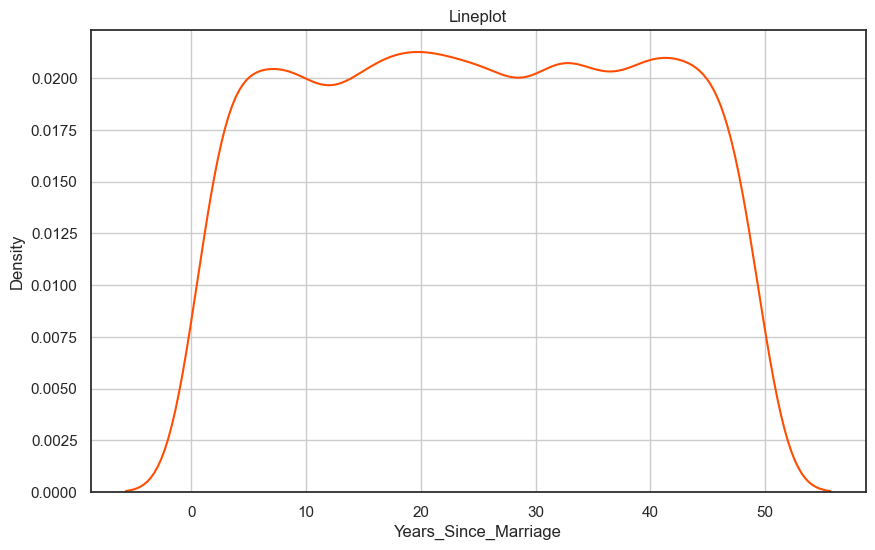

In [37]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,6))
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(data=df6,x=df6['Years_Since_Marriage'])
plt.title("Lineplot")
plt.grid(True)
plt.show()

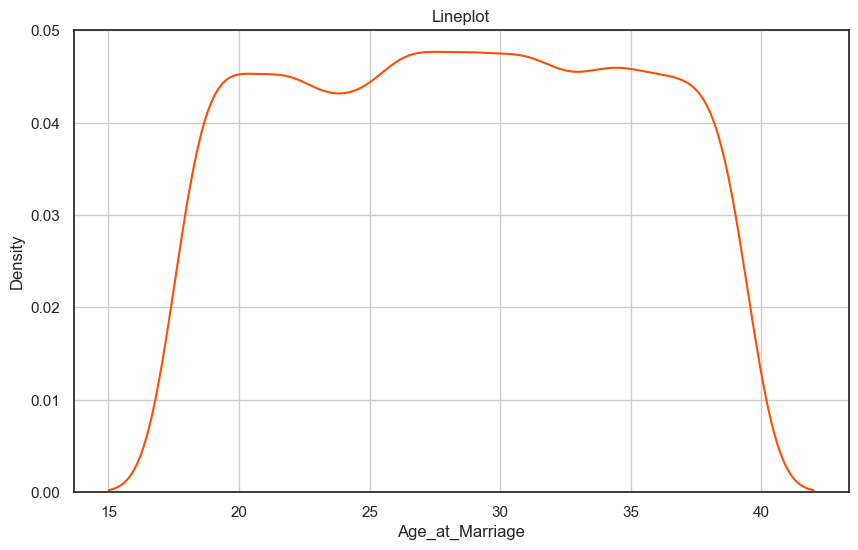

In [38]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,6))
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(data=df6,x=df6['Age_at_Marriage'])
plt.title("Lineplot")
plt.grid(True)
plt.show()

In [39]:
df6.columns

Index(['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage',
       'Gender_encoded', 'Education_Level_encoded', 'Caste_Match_encoded',
       'Religion_encoded', 'Parental_Approval_encoded', 'Urban_Rural_encoded',
       'Dowry_Exchanged_encoded', 'Marital_Satisfaction_encoded',
       'Divorce_Status_encoded', 'Income_Level_encoded',
       'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded', 'Marriage_Type_Encoded'],
      dtype='object')

In [40]:
x=df6.iloc[:,:-1]
y=df6.iloc[:,-1]

In [41]:
features_selction=SelectKBest(score_func=f_classif,k=10)
features_selction

,score_func,<function f_c...0023797796700>
,k,10


In [42]:
features_selction.fit(x,y)

,score_func,<function f_c...0023797796700>
,k,10


In [43]:
columns_choosed=x.columns[features_selction.get_support()]
columns_choosed

Index(['Children_Count', 'Years_Since_Marriage', 'Education_Level_encoded',
       'Caste_Match_encoded', 'Religion_encoded', 'Parental_Approval_encoded',
       'Dowry_Exchanged_encoded', 'Income_Level_encoded',
       'Spouse_Working_encoded', 'Inter-Caste_encoded'],
      dtype='object')

In [44]:
x1=df6[['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage',
       'Gender_encoded', 'Education_Level_encoded', 'Caste_Match_encoded',
       'Religion_encoded', 'Parental_Approval_encoded', 'Urban_Rural_encoded',
       'Dowry_Exchanged_encoded', 'Marital_Satisfaction_encoded',
       'Divorce_Status_encoded', 'Income_Level_encoded',
       'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded']]
y1=df6['Marriage_Type_Encoded'].squeeze()

In [45]:
x1

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded
0,23,5,34,1,0,0,1,0,1,0,2,1,2,0,0,0
1,28,3,42,0,3,1,1,2,0,2,1,0,2,0,0,1
2,39,0,25,1,2,1,2,2,0,0,2,0,0,0,0,0
3,26,0,12,0,3,0,1,2,1,2,1,0,0,0,1,0
4,32,1,41,0,0,1,1,1,0,2,2,0,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25,5,38,1,2,0,1,2,1,1,2,0,1,1,0,0
9996,31,4,1,0,3,1,1,1,0,0,0,0,1,0,0,0
9997,22,2,24,1,0,1,1,1,0,2,2,0,1,0,1,0
9998,39,3,28,1,2,1,2,2,1,0,2,0,2,0,0,0


In [46]:
try:
    x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.2,random_state=42)
except Exception as e:
    print(str(e))
else:
    print("no erroors in the code")
finally:
    print("final block is executed")

no erroors in the code
final block is executed


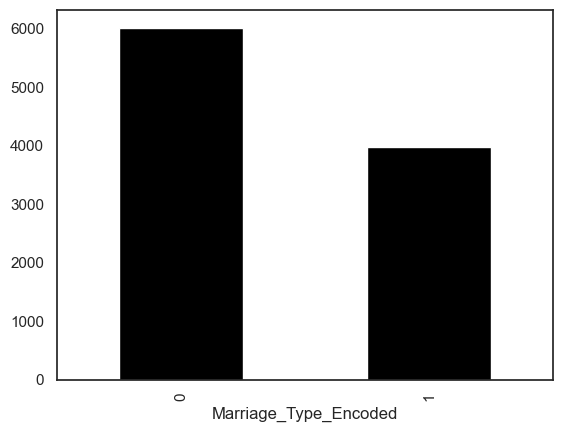

In [ ]:
df6['Marriage_Type_Encoded'].value_counts().plot(kind="bar",color='#000000')
plt.show()

In [48]:
Logistic_regression=LogisticRegression(n_jobs=-1,solver='liblinear')
Logistic_regression

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [49]:
Decision_tree=DecisionTreeClassifier(criterion='entropy',max_depth=10,max_features='sqrt',splitter='best',min_samples_split=10,min_samples_leaf=10)
Decision_tree

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
Random_forest=RandomForestClassifier(n_estimators=10,max_depth=10,min_samples_split=10,min_samples_leaf=10,max_features='sqrt',n_jobs=-1)
Random_forest

,n_estimators,10
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
knn_classifier=KNeighborsClassifier(n_jobs=-1,n_neighbors=10,weights='distance',algorithm='auto')
knn_classifier

,n_neighbors,10
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [52]:
svc_classifier=SVC(kernel='rbf',C=1.0,gamma='auto')
svc_classifier

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [53]:
c1=cross_val_score(Logistic_regression,x1,y1,scoring='accuracy',cv=10,n_jobs=-1)
print(np.mean(c1))

0.6022


In [54]:
pipeline1=Pipeline(steps=[
('cross_score1',cross_val_score(Logistic_regression,x1,y1,scoring='accuracy',cv=10,n_jobs=-1)) 
])
print(pipeline1)
pipeline2=Pipeline(steps=[
    ('cross_score2',cross_val_score(Decision_tree,x1,y1,scoring='accuracy',cv=10,n_jobs=-1))
])
print(pipeline2)
pipeline3=Pipeline(steps=[
    ('cross_score3',cross_val_score(Random_forest,x1,y1,scoring='accuracy',cv=10,n_jobs=-1))
])
print(pipeline3)
pipeline4=Pipeline(steps=[
    ('cross_score4',cross_val_score(knn_classifier,x1,y1,scoring='accuracy',cv=10,n_jobs=-1))
])
print(pipeline4)
pipeline5=Pipeline(steps=[
    ('cross_score5',cross_val_score(svc_classifier,x1,y1,scoring='accuracy',cv=10,n_jobs=-1))
])
print(pipeline5)
cross_value_dict={
    'cross1': pipeline1,
    'cross2': pipeline2,
    'cross3': pipeline3,
    'cross4': pipeline4,
    'cross5':pipeline5
}

for cros,cros1 in cross_value_dict.items():
    print(f"name is {cros}")
    print(f"{np.mean(cros1)}")    

Pipeline(steps=[('cross_score1',
                 array([0.602, 0.602, 0.602, 0.602, 0.602, 0.602, 0.602, 0.602, 0.603,
       0.603]))])
Pipeline(steps=[('cross_score2',
                 array([0.568, 0.566, 0.559, 0.573, 0.57 , 0.569, 0.561, 0.583, 0.564,
       0.567]))])
Pipeline(steps=[('cross_score3',
                 array([0.595, 0.597, 0.581, 0.6  , 0.592, 0.599, 0.595, 0.586, 0.58 ,
       0.594]))])
Pipeline(steps=[('cross_score4',
                 array([0.56 , 0.536, 0.546, 0.583, 0.571, 0.554, 0.536, 0.553, 0.564,
       0.559]))])
Pipeline(steps=[('cross_score5',
                 array([0.586, 0.588, 0.601, 0.603, 0.598, 0.593, 0.587, 0.587, 0.588,
       0.592]))])
name is cross1
0.6022
name is cross2
0.568
name is cross3
0.5919000000000001
name is cross4
0.5562
name is cross5
0.5923


In [ ]:
pipeline6=Pipeline(steps=[
('grid_score1',GridSearchCV(estimator=Decision_tree,param_grid={'criterion':['gini','entropy'],'max_depth':[2,4,6,8,10],'min_samples_split':[10,20,30,40,50]},scoring='accuracy',n_jobs=-1)) 
])

pipeline7=Pipeline(steps=[
    ('grid_score2',GridSearchCV(estimator=Random_forest,param_grid={'criterion':['gini','entropy'],'max_depth':[2,4,6,8,10],'min_samples_split':[10,20,30,40,50]},scoring='accuracy',n_jobs=-1))
])

pipeline8=Pipeline(steps=[
    ('grid_score3',GridSearchCV(estimator=knn_classifier,param_grid={'n_neighbors': [5, 10, 20], 'weights': ['uniform', 'distance']},scoring='accuracy',n_jobs=-1))
])

pipeline9=Pipeline(steps=[
    ('grid_score4',GridSearchCV(estimator=svc_classifier,param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},scoring='accuracy',n_jobs=-1))
])


grid_value_dict={
    'grid1': pipeline6,
    'grid2': pipeline7,
    'grid3': pipeline8,
    'grid4': pipeline9,
}

for grid,grid1 in grid_value_dict.items():
    print(f"name is {grid}")
    print("-------------------")
    print(f"{grid1}")
    print("---------fitting some data to find the accuarcy-----------")
    grid1.fit(x_train,y_train) 

final_score = pipeline6.named_steps['grid_score1']
print(final_score.best_score_)
print(final_score.best_params_)


In [60]:
df6.columns

Index(['Age_at_Marriage', 'Children_Count', 'Years_Since_Marriage',
       'Gender_encoded', 'Education_Level_encoded', 'Caste_Match_encoded',
       'Religion_encoded', 'Parental_Approval_encoded', 'Urban_Rural_encoded',
       'Dowry_Exchanged_encoded', 'Marital_Satisfaction_encoded',
       'Divorce_Status_encoded', 'Income_Level_encoded',
       'Spouse_Working_encoded', 'Inter-Caste_encoded',
       'Inter-Religion_encoded', 'Marriage_Type_Encoded'],
      dtype='object')

In [61]:
x1

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded
0,23,5,34,1,0,0,1,0,1,0,2,1,2,0,0,0
1,28,3,42,0,3,1,1,2,0,2,1,0,2,0,0,1
2,39,0,25,1,2,1,2,2,0,0,2,0,0,0,0,0
3,26,0,12,0,3,0,1,2,1,2,1,0,0,0,1,0
4,32,1,41,0,0,1,1,1,0,2,2,0,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25,5,38,1,2,0,1,2,1,1,2,0,1,1,0,0
9996,31,4,1,0,3,1,1,1,0,0,0,0,1,0,0,0
9997,22,2,24,1,0,1,1,1,0,2,2,0,1,0,1,0
9998,39,3,28,1,2,1,2,2,1,0,2,0,2,0,0,0


In [69]:
pipeline10=Pipeline(steps=[
    ('Logistic_regression',Logistic_regression)
])
pipeline11=Pipeline(steps=[
    ("Decision_tree",Decision_tree)
])
pipeline12=Pipeline(steps=[
    ('Random_forest',Random_forest)
])
pipeline13=Pipeline(steps=[
    ("Knn_Classifier",knn_classifier)
])
pipeline14=Pipeline(steps=[
    ('svc_classifier',svc_classifier)
])

model_dict={
    "Logistic":pipeline10,
    "Decision":pipeline11,
    "Random":pipeline12,
    "knn":pipeline13,
    "svc":pipeline14
}

for name, model in model_dict.items():
    
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(f"{name} -- {y_pred}")

Logistic -- [0 0 0 ... 0 0 0]
Decision -- [0 0 0 ... 0 1 1]
Random -- [0 0 0 ... 0 0 0]
knn -- [1 0 0 ... 0 1 0]
svc -- [0 0 0 ... 0 0 0]


In [92]:
joblib.dump(Logistic_regression,'../ModelsJobs/Logistic_regression.joblib')

['../ModelsJobs/Logistic_regression.joblib']

In [96]:
joblib.dump(svc_classifier,'../ModelsJobs/svc_classifier.joblib')

['../ModelsJobs/svc_classifier.joblib']

In [78]:
df6.describe()

,Age_at_Marriage,Children_Count,Years_Since_Marriage,Gender_encoded,Education_Level_encoded,Caste_Match_encoded,Religion_encoded,Parental_Approval_encoded,Urban_Rural_encoded,Dowry_Exchanged_encoded,Marital_Satisfaction_encoded,Divorce_Status_encoded,Income_Level_encoded,Spouse_Working_encoded,Inter-Caste_encoded,Inter-Religion_encoded,Marriage_Type_Encoded
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,28.503800,2.508800,24.973800,0.489100,1.42210,0.707100,1.352900,1.598100,0.604600,0.699400,1.200800,0.100100,1.296000,0.504700,0.29680,0.202800,0.397800
std,6.279564,1.695467,14.054838,0.499906,1.28347,0.455116,0.914464,0.668596,0.488961,0.899734,0.871295,0.300148,0.782972,0.500003,0.45687,0.402105,0.489468
min,18.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,23.000000,1.000000,13.000000,0.000000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
50%,29.000000,3.000000,25.000000,0.000000,2.00000,1.000000,1.000000,2.000000,1.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.00000,0.000000,0.000000
75%,34.000000,4.000000,37.000000,1.000000,3.00000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,0.000000,2.000000,1.000000,1.00000,0.000000,1.000000
max,39.000000,5.000000,49.000000,1.000000,3.00000,1.000000,4.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.00000,1.000000,1.000000


In [76]:
df3[['Marriage_Type','Marriage_Type_Encoded']].value_counts()

Marriage_Type  Marriage_Type_Encoded
Arranged       0                        6022
Love           1                        3978
Name: count, dtype: int64

In [88]:
df3[['Dowry_Exchanged','Dowry_Exchanged_encoded']].value_counts()

Dowry_Exchanged  Dowry_Exchanged_encoded
No               0                          6002
Yes              2                          2996
Not Disclosed    1                          1002
Name: count, dtype: int64

In [87]:
df3[['Marital_Satisfaction','Marital_Satisfaction_encoded']].value_counts()

Marital_Satisfaction  Marital_Satisfaction_encoded
Medium                2                               5001
High                  0                               2993
Low                   1                               2006
Name: count, dtype: int64

In [86]:
df3[['Religion','Religion_encoded']].value_counts()

Religion   Religion_encoded
Hindu      1                   6034
Muslim     2                   1939
Christian  0                    990
Others     3                    531
Sikh       4                    506
Name: count, dtype: int64

In [85]:
df3[['Education_Level','Education_Level_encoded']].value_counts()

Education_Level  Education_Level_encoded
Graduate         0                          3943
School           3                          3073
Postgraduate     2                          2018
PhD              1                           966
Name: count, dtype: int64

In [83]:
df3[['Income_Level','Income_Level_encoded']].value_counts()

Income_Level  Income_Level_encoded
Middle        2                       4983
Low           1                       2994
High          0                       2023
Name: count, dtype: int64

In [82]:
df3[['Divorce_Status','Divorce_Status_encoded']].value_counts()

Divorce_Status  Divorce_Status_encoded
No              0                         8999
Yes             1                         1001
Name: count, dtype: int64

In [81]:
df3[['Spouse_Working','Spouse_Working_encoded']].value_counts()

Spouse_Working  Spouse_Working_encoded
Yes             1                         5047
No              0                         4953
Name: count, dtype: int64

In [80]:
df3[['Inter-Caste','Inter-Caste_encoded']].value_counts()

Inter-Caste  Inter-Caste_encoded
No           0                      7032
Yes          1                      2968
Name: count, dtype: int64

In [79]:
df3[['Inter-Religion','Inter-Religion_encoded']].value_counts()

Inter-Religion  Inter-Religion_encoded
No              0                         7972
Yes             1                         2028
Name: count, dtype: int64